# Notebook 4 — Modelo supervisado de clasificación de brotes

## Contexto

Con el panel mensual del NB3 construimos un clasificador que predice si una
sede tendrá un **brote activo de sarampión** (`brote = 1`) en un mes dado.

### Desafíos clave de este dataset
| Desafío | Detalle | Solución |
|---|---|---|
| **Desbalance extremo** | 11:1 (363 sin brote vs 33 con brote) | SMOTE + class_weight |
| **Pocos brotes en train** | Solo 4 en 2016-2024 | Walk-forward CV temporal |
| **Serie de tiempo** | No se puede barajar aleatoriamente | TimeSeriesSplit |
| **Nulos en features** | pax_lag4 (246), who_casos_mex (36) | Imputación por estrategia |

### Estrategia de validación
Dado que casi todos los brotes están en 2025-2026, usamos **walk-forward
cross-validation** con ventanas deslizantes — nunca entrenamos con datos
del futuro para predecir el pasado.

### Modelos comparados
1. **Logistic Regression** — baseline lineal, interpretable
2. **Random Forest** — captura no-linealidades, robusto
3. **XGBoost** — mejor rendimiento esperado, maneja desbalance nativamente


---
## 0. Imports y configuración

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing   import StandardScaler
from sklearn.impute          import SimpleImputer
from sklearn.pipeline        import Pipeline
from sklearn.metrics         import (classification_report, confusion_matrix,
                                     roc_auc_score, roc_curve,
                                     precision_recall_curve, average_precision_score,
                                     f1_score, precision_score, recall_score)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.inspection      import permutation_importance
from imblearn.over_sampling  import SMOTE
from imblearn.pipeline       import Pipeline as ImbPipeline

try:
    from xgboost import XGBClassifier
    XGBOOST_OK = True
except ImportError:
    print("⚠️  XGBoost no disponible — instalar con: pip install xgboost")
    XGBOOST_OK = False

sns.set_theme(style='whitegrid', palette='muted')

DATA_RAW       = 'content/data/raw/'
DATA_PROCESSED = 'content/data/processed/'
OUTPUT_FIGURES = 'content/reports/figures/'
OUTPUT_MODELS  = 'content/models/'

for path in [DATA_RAW, DATA_PROCESSED, OUTPUT_FIGURES, OUTPUT_MODELS]:
    os.makedirs(path, exist_ok=True)

CIUDAD_COLORS = {'CDMX': '#4e8ec4', 'Guadalajara': '#d4a200', 'Monterrey': '#55a855'}
RANDOM_STATE  = 42

print("✅ Imports OK")
print(f"   XGBoost disponible: {XGBOOST_OK}")


✅ Imports OK
   XGBoost disponible: True


In [ ]:
# CELDA TEMPORAL
import pandas as pd

sefe_2026 = pd.read_csv('/content/content/data/raw/2026_efes_abierto_090326.csv',
                         encoding='latin1')
sefe_2026['FECHA_DIAGNOSTICO'] = pd.to_datetime(
    sefe_2026['FECHA_DIAGNOSTICO'], errors='coerce', dayfirst=False
)
sar_2026 = sefe_2026[sefe_2026['DIAGNOSTICO'] == 1]

print(f"Total casos Sarampión SEFE 2026: {len(sar_2026)}")
print(f"Fecha más reciente: {sar_2026['FECHA_DIAGNOSTICO'].max()}")
print(f"Fecha más antigua : {sar_2026['FECHA_DIAGNOSTICO'].min()}")
print(f"\nCasos por semana ISO:")
sar_2026['semana'] = sar_2026['FECHA_DIAGNOSTICO'].dt.isocalendar().week
sar_2026['anio']   = sar_2026['FECHA_DIAGNOSTICO'].dt.isocalendar().year
print(sar_2026.groupby(['anio','semana']).size().to_string())

Total casos Sarampión SEFE 2026: 7212
Fecha más reciente: 2026-12-03 00:00:00
Fecha más antigua : 2026-01-02 00:00:00

Casos por semana ISO:
anio  semana
2026  1         105
      6         294
      10        193
      14        252
      18        293
      23        451
      27        125
      31         35
      32         39
      36        429
      40        330
      44         17
      45        330
      49        455


---
## 1. Construcción del dataset de features

Cargamos el panel del NB3 y añadimos features de otras enfermedades como proxies de vigilancia epidemiológica activa.

In [ ]:
# ── 1.1 Panel del NB3 ────────────────────────────────────────────────────
panel = pd.read_csv(DATA_PROCESSED + 'panel_mensual_completo.csv',
                    parse_dates=['fecha'])
panel = panel.sort_values(['ciudad_sede','fecha']).reset_index(drop=True)

print(f"Panel NB3: {panel.shape}")
print(f"Rango: {panel['fecha'].min().date()} → {panel['fecha'].max().date()}")
print(f"Brotes: {panel['brote'].sum()} / {len(panel)} ({panel['brote'].mean()*100:.1f}%)")


Panel NB3: (363, 22)
Rango: 2016-01-01 → 2026-01-01
Brotes: 14 / 363 (3.9%)


In [ ]:
# ── 1.2 Features de otras enfermedades (boletín DGE) ─────────────────────
# Varicela, Escarlatina, Erisipela como proxies de actividad epidémica
boletin = pd.read_csv(DATA_RAW + 'boletin_epidemiologico_2016_2026.csv',
                      parse_dates=['fecha_inicio'])

SEDES_MAP = {
    'Ciudad de México': 'CDMX',
    'Jalisco'         : 'Guadalajara',
    'Nuevo León'      : 'Monterrey',
}

enf_features = (
    boletin[
        (boletin['sexo'] == 'H') &
        (boletin['entidad_federativa'].isin(SEDES_MAP.keys()))
    ]
    .copy()
)
enf_features['ciudad_sede'] = enf_features['entidad_federativa'].map(SEDES_MAP)
enf_features['fecha'] = enf_features['fecha_inicio'].dt.to_period('M').dt.to_timestamp()

enf_pivot = (
    enf_features
    .groupby(['fecha','ciudad_sede','enfermedad'])['casos_semana']
    .sum()
    .reset_index()
    .pivot_table(index=['fecha','ciudad_sede'], columns='enfermedad',
                 values='casos_semana', aggfunc='sum')
    .reset_index()
    .fillna(0)
)
enf_pivot.columns = ['fecha','ciudad_sede'] + [
    f'casos_{c.lower()}' for c in enf_pivot.columns[2:]
]

# Renombrar para claridad
enf_pivot = enf_pivot.rename(columns={
    'casos_sarampion'  : 'casos_sarampion_raw',   # ya en panel como casos_sarampion
    'casos_varicela'   : 'varicela_mes',
    'casos_escarlatina': 'escarlatina_mes',
    'casos_erisipela'  : 'erisipela_mes',
    'casos_rubeola'    : 'rubeola_mes',
})

panel = panel.merge(
    enf_pivot[['fecha','ciudad_sede','varicela_mes','escarlatina_mes',
               'erisipela_mes','rubeola_mes']],
    on=['fecha','ciudad_sede'], how='left'
).fillna({'varicela_mes':0,'escarlatina_mes':0,'erisipela_mes':0,'rubeola_mes':0})

print(f"Panel con features enfermedades: {panel.shape}")


Panel con features enfermedades: (363, 26)


In [ ]:
# ── 1.3 Features derivadas ────────────────────────────────────────────────
for ciudad in ['CDMX','Guadalajara','Monterrey']:
    mask = panel['ciudad_sede'] == ciudad

    # Rolling 3m de otras enfermedades (proxy de vigilancia activa)
    panel.loc[mask, 'varicela_rolling3'] = (
        panel.loc[mask, 'varicela_mes'].rolling(3, min_periods=1).mean()
    )
    # Variación mensual de pasajeros (delta)
    panel.loc[mask, 'pax_delta'] = (
        panel.loc[mask, 'pasajeros_internacionales'].pct_change().fillna(0)
    )
    # Acumulado de brotes últimos 6 meses (memoria epidémica)
    panel.loc[mask, 'brotes_6m'] = (
        panel.loc[mask, 'brote'].rolling(6, min_periods=1).sum().shift(1).fillna(0)
    )

# Score de riesgo del NB1 por sede (constante)
score_sede = {
    'CDMX'       : 4.88,
    'Guadalajara': 1.33,
    'Monterrey'  : 3.90,
}
panel['score_riesgo_nb1'] = panel['ciudad_sede'].map(score_sede)

# Dummies de ciudad sede
dummies = pd.get_dummies(panel['ciudad_sede'], prefix='sede', drop_first=False)
panel = pd.concat([panel, dummies], axis=1)

print(f"Panel final: {panel.shape}")
print(f"\nDistribución del target:")
print(panel['brote'].value_counts().to_string())
print(f"Ratio desbalance: {(panel['brote']==0).sum()/(panel['brote']==1).sum():.1f}:1")


Panel final: (363, 33)

Distribución del target:
brote
0    349
1     14
Ratio desbalance: 24.9:1


---
## 2. Selección de features e imputación de nulos

### Estrategia de imputación
| Feature | Nulos | Estrategia |
|---|---|---|
| `pax_lag4` | 246 | **Eliminar** — demasiados nulos, lag=4 no es sig. para GDL ni MTY |
| `pax_lag0` | 134 | **Eliminar** — reemplazar por `pasajeros_internacionales` directamente |
| `who_casos_mex` | 36 | **Imputar con 0** — sin reporte WHO = sin casos notificados |
| `pax_sede` | 13 | **Imputar con mediana por mes** — estacionalidad conocida |
| `pax_int_mty` | 39 | **Imputar con mediana por mes** |
| `casos_lag1` | 3 | **Imputar con 0** — inicio de serie |


In [ ]:
# Columnas a eliminar (demasiados nulos o redundantes)
COLS_ELIMINAR = [
    'pax_lag4',          # 246 nulos
    'pax_lag0',          # 134 nulos — reemplazado por pasajeros_internacionales
    'casos_sarampion_raw',  # duplicado de casos_sarampion
    'mes_num',           # capturado por semana_sin y semana_cos
]

# Features finales para el modelo
FEATURE_COLS = [
    # Temporales
    'anio', 'semana_sin', 'semana_cos',
    # Pasajeros
    'pasajeros_internacionales', 'pasajeros_nacionales',
    'operaciones_vuelos_internacionales', 'pax_delta',
    # Sarampión lags
    'casos_sarampion', 'casos_lag1', 'brote_lag1', 'brotes_6m',
    'casos_rolling3', 'anomalias_mes', 'zscore_max_mes',
    # Otras enfermedades
    'varicela_mes', 'escarlatina_mes', 'erisipela_mes', 'rubeola_mes',
    'varicela_rolling3',
    # WHO + score NB1
    'who_casos_mex', 'score_riesgo_nb1',
    # Dummies sede
    'sede_CDMX', 'sede_Guadalajara', 'sede_Monterrey',
]

TARGET = 'brote'

# Imputaciones previas al pipeline
panel['who_casos_mex'] = panel['who_casos_mex'].fillna(0)
panel['casos_lag1']    = panel['casos_lag1'].fillna(0)
panel['brote_lag1']    = panel['brote_lag1'].fillna(0)

# Imputar pax_sede y pax_int_mty con mediana por mes
for col in ['pax_sede', 'pax_int_mty', 'pasajeros_internacionales']:
    if col in panel.columns:
        med = panel.groupby('mes_num')[col].transform('median')
        panel[col] = panel[col].fillna(med)

X = panel[FEATURE_COLS].copy()
y = panel[TARGET].copy()

print(f"X shape: {X.shape}")
print(f"y distribución: {y.value_counts().to_dict()}")
print(f"\nNulos restantes en X:")
nulos = X.isnull().sum()
print(nulos[nulos > 0].to_string() if nulos.sum() > 0 else "  Ninguno ✅")


X shape: (363, 24)
y distribución: {0: 349, 1: 14}

Nulos restantes en X:
  Ninguno ✅


---
## 3. División temporal train / test

Usamos **corte temporal en enero 2025** — todo lo anterior es train,
2025-2026 es test. Esto simula el escenario real: entrenar con datos
históricos y predecir el brote activo.

> ⚠️ **Limitación importante:** Solo hay 4 brotes en train (2020 y 2024).
> El modelo aprenderá principalmente el patrón de no-brote. Por esto
> evaluamos con **Precision-Recall AUC** (más informativo que ROC-AUC
> en datasets desbalanceados) y priorizamos **recall** sobre precisión
> — en epidemiología es más costoso un falso negativo que un falso positivo.


Train: 324 filas | brotes: 4 (1.2%)
Test:  39  filas | brotes: 10  (25.6%)


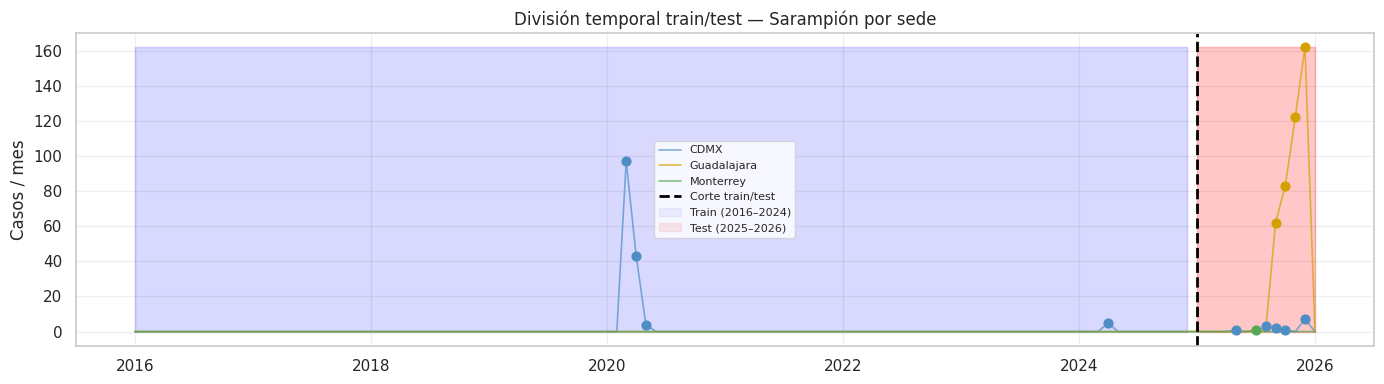

In [ ]:
CORTE_TEST = pd.Timestamp('2025-01-01')

mask_train = panel['fecha'] < CORTE_TEST
mask_test  = panel['fecha'] >= CORTE_TEST

X_train, y_train = X[mask_train].copy(), y[mask_train].copy()
X_test,  y_test  = X[mask_test].copy(),  y[mask_test].copy()

print(f"Train: {mask_train.sum()} filas | brotes: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"Test:  {mask_test.sum()}  filas | brotes: {y_test.sum()}  ({y_test.mean()*100:.1f}%)")

# Visualizar split temporal
fig, ax = plt.subplots(figsize=(14, 4))
for ciudad, color in CIUDAD_COLORS.items():
    sub = panel[panel['ciudad_sede'] == ciudad].sort_values('fecha')
    ax.plot(sub['fecha'], sub['casos_sarampion'],
            color=color, linewidth=1.2, alpha=0.7, label=ciudad)
    # Marcar brotes
    b = sub[sub['brote'] == 1]
    ax.scatter(b['fecha'], b['casos_sarampion'], color=color, s=40, zorder=5)

ax.axvline(CORTE_TEST, color='black', linewidth=2, linestyle='--', label='Corte train/test')
ax.fill_between(panel['fecha'], 0, panel['casos_sarampion'].max(),
                where=panel['fecha'] < CORTE_TEST,
                alpha=0.05, color='blue', label='Train (2016–2024)')
ax.fill_between(panel['fecha'], 0, panel['casos_sarampion'].max(),
                where=panel['fecha'] >= CORTE_TEST,
                alpha=0.08, color='red', label='Test (2025–2026)')
ax.set_title('División temporal train/test — Sarampión por sede', fontsize=12)
ax.set_ylabel('Casos / mes')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_FIGURES}/train_test_split.png', dpi=150)
plt.show()


---
## 4. Entrenamiento de modelos

Usamos **pipelines** con imputación + escalado + clasificador.
Para manejar el desbalance aplicamos `class_weight='balanced'` en todos
los modelos. SMOTE se aplica solo en el pipeline de Random Forest para
comparar su efecto.


In [ ]:
# ── Definir pipelines ─────────────────────────────────────────────────────
imputer = SimpleImputer(strategy='median')
scaler  = StandardScaler()

modelos = {
    'Logistic Regression': Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('scl', StandardScaler()),
        ('clf', LogisticRegression(
            class_weight='balanced',
            max_iter=1000,
            random_state=RANDOM_STATE,
            C=0.1,
        )),
    ]),

    'Random Forest': ImbPipeline([
        ('imp',   SimpleImputer(strategy='median')),
        ('smote', SMOTE(random_state=RANDOM_STATE, k_neighbors=2)),
        ('clf',   RandomForestClassifier(
            n_estimators=300,
            class_weight='balanced',
            max_depth=5,
            min_samples_leaf=3,
            random_state=RANDOM_STATE,
        )),
    ]),

    'Gradient Boosting': Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('clf', GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.8,
            random_state=RANDOM_STATE,
        )),
    ]),
}

if XGBOOST_OK:
    scale_pos = int((y_train == 0).sum() / max(y_train.sum(), 1))
    modelos['XGBoost'] = Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('clf', XGBClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            scale_pos_weight=scale_pos,
            eval_metric='logloss',
            random_state=RANDOM_STATE,
            verbosity=0,
        )),
    ])

print(f"Modelos definidos: {list(modelos.keys())}")
print(f"Scale_pos_weight XGBoost: {scale_pos if XGBOOST_OK else 'N/A'}")


Modelos definidos: ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'XGBoost']
Scale_pos_weight XGBoost: 80


In [ ]:
# ── Walk-forward cross-validation ─────────────────────────────────────────
# TimeSeriesSplit sobre el train set
# Con solo 4 brotes en train, usamos n_splits=3 para no vaciar los folds
tscv = TimeSeriesSplit(n_splits=3, gap=0)

cv_results = {}
print("Walk-forward CV (train set 2016–2024):\n")

for nombre, pipe in modelos.items():
    f1s, rocs, prs = [], [], []

    for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):
        X_tr  = X_train.iloc[tr_idx]
        y_tr  = y_train.iloc[tr_idx]
        X_val = X_train.iloc[val_idx]
        y_val = y_train.iloc[val_idx]

        if y_tr.sum() == 0 or y_val.sum() == 0:
            continue   # fold sin brotes — skip

        try:
            pipe.fit(X_tr, y_tr)
            y_prob = pipe.predict_proba(X_val)[:, 1]
            y_pred = (y_prob >= 0.3).astype(int)  # umbral bajo por recall

            f1s.append(f1_score(y_val, y_pred, zero_division=0))
            rocs.append(roc_auc_score(y_val, y_prob))
            prs.append(average_precision_score(y_val, y_prob))
        except Exception as e:
            print(f"  {nombre} fold {fold}: {e}")

    cv_results[nombre] = {
        'f1_mean'  : np.mean(f1s)   if f1s  else np.nan,
        'roc_mean' : np.mean(rocs)  if rocs else np.nan,
        'pr_mean'  : np.mean(prs)   if prs  else np.nan,
        'n_folds'  : len(f1s),
    }

    print(f"  {nombre:25s}: F1={cv_results[nombre]['f1_mean']:.3f} | "
          f"ROC-AUC={cv_results[nombre]['roc_mean']:.3f} | "
          f"PR-AUC={cv_results[nombre]['pr_mean']:.3f} "
          f"({cv_results[nombre]['n_folds']} folds)")


Walk-forward CV (train set 2016–2024):

  Logistic Regression      : F1=0.000 | ROC-AUC=0.950 | PR-AUC=0.200 (1 folds)
  Random Forest            : F1=1.000 | ROC-AUC=1.000 | PR-AUC=1.000 (1 folds)
  Gradient Boosting        : F1=0.000 | ROC-AUC=0.975 | PR-AUC=0.333 (1 folds)
  XGBoost                  : F1=1.000 | ROC-AUC=1.000 | PR-AUC=1.000 (1 folds)


In [ ]:
# ── Entrenar todos los modelos en el train completo ─────────────────────
print("Entrenando modelos en train completo (2016–2024)...")
for nombre, pipe in modelos.items():
    pipe.fit(X_train, y_train)
    print(f"  ✅ {nombre}")


Entrenando modelos en train completo (2016–2024)...
  ✅ Logistic Regression
  ✅ Random Forest
  ✅ Gradient Boosting
  ✅ XGBoost


---
## 5. Evaluación en el conjunto de test (2025–2026)

Evaluamos con **umbral de clasificación = 0.30** en lugar de 0.50 —
en epidemiología preferimos recall alto (no perder brotes reales)
sobre precisión alta (evitar falsas alarmas).


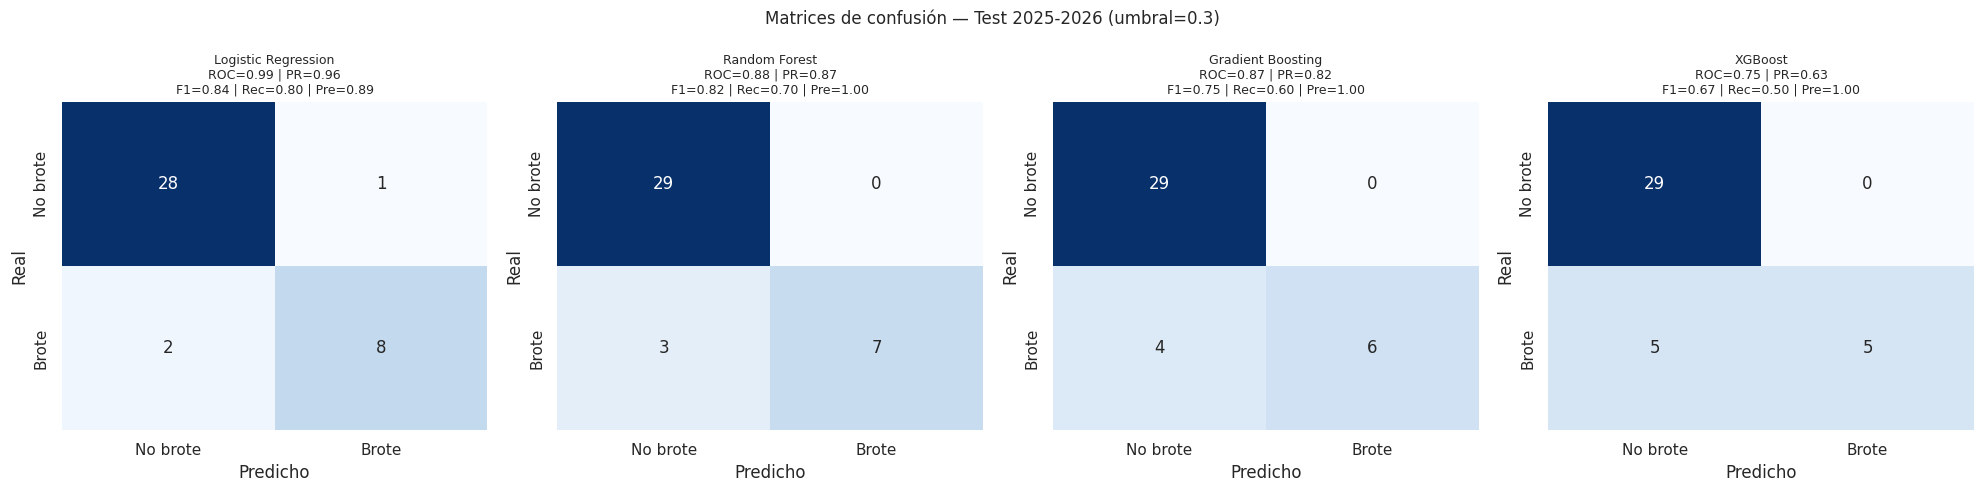

In [ ]:
UMBRAL = 0.30

test_results = {}
fig, axes = plt.subplots(1, len(modelos), figsize=(5*len(modelos), 5))
if len(modelos) == 1:
    axes = [axes]

for ax, (nombre, pipe) in zip(axes, modelos.items()):
    y_prob = pipe.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= UMBRAL).astype(int)

    cm = confusion_matrix(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)
    pr  = average_precision_score(y_test, y_prob)
    f1  = f1_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    pre = precision_score(y_test, y_pred, zero_division=0)

    test_results[nombre] = {
        'roc_auc': roc, 'pr_auc': pr,
        'f1': f1, 'recall': rec, 'precision': pre,
        'y_prob': y_prob, 'y_pred': y_pred,
    }

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No brote','Brote'],
                yticklabels=['No brote','Brote'], ax=ax, cbar=False)
    ax.set_title(f'{nombre}\nROC={roc:.2f} | PR={pr:.2f}\nF1={f1:.2f} | Rec={rec:.2f} | Pre={pre:.2f}',
                 fontsize=9)
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')

plt.suptitle(f'Matrices de confusión — Test 2025-2026 (umbral={UMBRAL})', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_FIGURES}/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


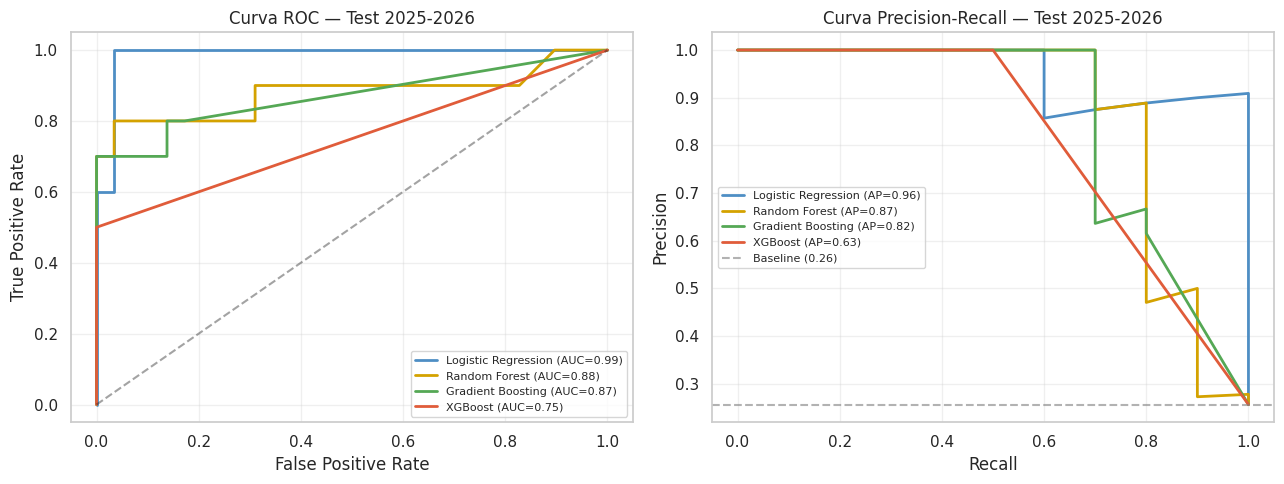


Resumen comparativo de modelos (Test 2025-2026):
                      roc_auc    pr_auc        f1 recall precision
Logistic Regression  0.986207  0.957298  0.842105    0.8  0.888889
Random Forest         0.87931  0.866667  0.823529    0.7       1.0
Gradient Boosting    0.868966  0.817949      0.75    0.6       1.0
XGBoost                  0.75  0.628205  0.666667    0.5       1.0

Mejor modelo por PR-AUC: Logistic Regression


In [ ]:
# ── Curvas ROC y Precision-Recall ─────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
palette = ['#4e8ec4','#d4a200','#55a855','#e05c3a']

for (nombre, res), color in zip(test_results.items(), palette):
    # ROC
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax1.plot(fpr, tpr, color=color, linewidth=2,
             label=f"{nombre} (AUC={res['roc_auc']:.2f})")

    # PR
    pre_c, rec_c, _ = precision_recall_curve(y_test, res['y_prob'])
    ax2.plot(rec_c, pre_c, color=color, linewidth=2,
             label=f"{nombre} (AP={res['pr_auc']:.2f})")

ax1.plot([0,1],[0,1],'k--',alpha=0.4)
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Curva ROC — Test 2025-2026')
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

# Baseline PR (proporción de positivos)
baseline_pr = y_test.mean()
ax2.axhline(baseline_pr, color='gray', linestyle='--', alpha=0.6,
            label=f'Baseline ({baseline_pr:.2f})')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Curva Precision-Recall — Test 2025-2026')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_FIGURES}/roc_pr_curves.png', dpi=150)
plt.show()

# Tabla comparativa
print("\nResumen comparativo de modelos (Test 2025-2026):")
resumen_df = pd.DataFrame(test_results).T[['roc_auc','pr_auc','f1','recall','precision']]
resumen_df = resumen_df.round(3).sort_values('pr_auc', ascending=False)
print(resumen_df.to_string())
print(f"\nMejor modelo por PR-AUC: {resumen_df['pr_auc'].idxmax()}")


---
## 6. Importancia de features

Modelo seleccionado: Logistic Regression


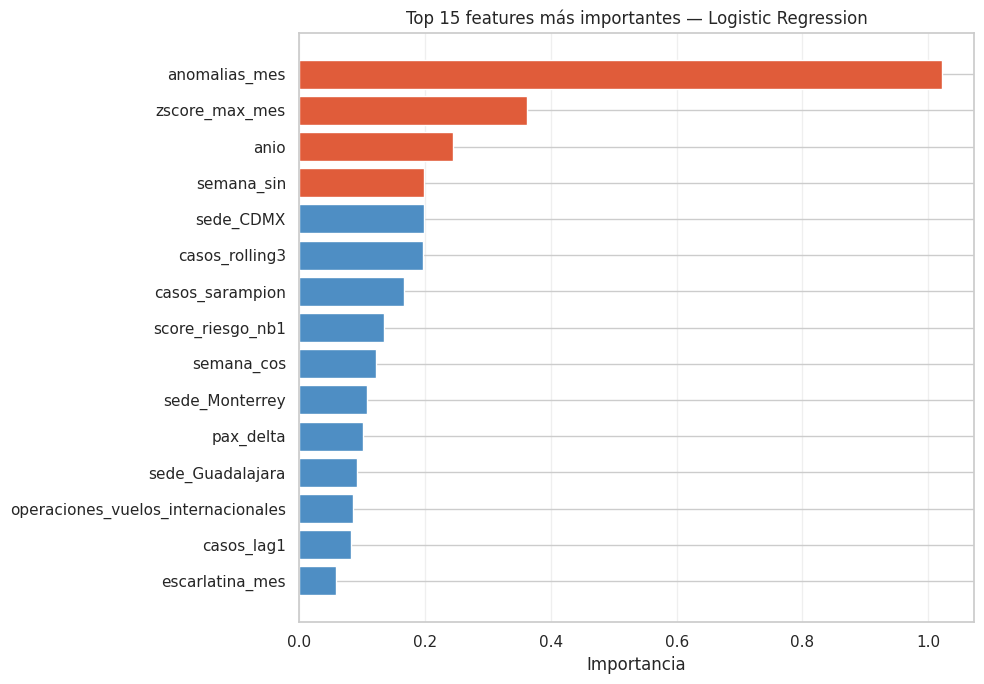


Top 10 features:
         feature  importance
   anomalias_mes    1.021537
  zscore_max_mes    0.362092
            anio    0.243972
      semana_sin    0.198991
       sede_CDMX    0.198869
  casos_rolling3    0.196678
 casos_sarampion    0.166656
score_riesgo_nb1    0.135306
      semana_cos    0.122124
  sede_Monterrey    0.107517


In [ ]:
# Usar el mejor modelo por PR-AUC
mejor_nombre = pd.DataFrame(test_results).T['pr_auc'].astype(float).idxmax()
mejor_modelo  = modelos[mejor_nombre]
print(f"Modelo seleccionado: {mejor_nombre}")

# Importancia del clasificador final
clf = mejor_modelo.named_steps['clf']

if hasattr(clf, 'feature_importances_'):
    importancias = clf.feature_importances_
elif hasattr(clf, 'coef_'):
    importancias = np.abs(clf.coef_[0])
else:
    importancias = np.zeros(len(FEATURE_COLS))

imp_df = (
    pd.DataFrame({'feature': FEATURE_COLS, 'importance': importancias})
    .sort_values('importance', ascending=True)
    .tail(15)
)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e05c3a' if imp > imp_df['importance'].quantile(0.75) else '#4e8ec4'
          for imp in imp_df['importance']]
ax.barh(imp_df['feature'], imp_df['importance'], color=colors, edgecolor='white')
ax.set_title(f'Top 15 features más importantes — {mejor_nombre}', fontsize=12)
ax.set_xlabel('Importancia')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_FIGURES}/feature_importance.png', dpi=150)
plt.show()

print("\nTop 10 features:")
print(imp_df.tail(10)[['feature','importance']].sort_values('importance', ascending=False).to_string(index=False))


---
## 7. Predicción de riesgo durante el Mundial 2026

Aplicamos el mejor modelo a las semanas del Mundial (jun–jul 2026)
y calculamos la **probabilidad de brote activo** por sede.


In [ ]:
# Filtrar semanas del Mundial (jun-jul 2026)
mundial_mask = (
    (panel['fecha'] >= pd.Timestamp('2026-06-01')) &
    (panel['fecha'] <= pd.Timestamp('2026-07-31'))
)
panel_mundial = panel[mundial_mask].copy()

if len(panel_mundial) == 0:
    print("⚠️  No hay datos del Mundial en el panel (el boletín llega hasta ene-2026)")
    print("   Usando los últimos datos disponibles (2026) como proxy")
    panel_mundial = panel[panel['fecha'].dt.year == 2026].copy()

X_mundial = panel_mundial[FEATURE_COLS].copy()

# Predecir con el mejor modelo
y_prob_mundial = mejor_modelo.predict_proba(X_mundial)[:, 1]
panel_mundial  = panel_mundial.copy()
panel_mundial['prob_brote']  = y_prob_mundial
panel_mundial['pred_brote']  = (y_prob_mundial >= UMBRAL).astype(int)
panel_mundial['nivel_riesgo'] = pd.cut(
    y_prob_mundial,
    bins=[0, 0.2, 0.4, 0.6, 1.0],
    labels=['Bajo', 'Moderado', 'Alto', 'Muy alto']
)

print("Predicción de riesgo de brote durante el Mundial 2026:")
print(panel_mundial[['fecha','ciudad_sede','casos_sarampion',
                      'prob_brote','pred_brote','nivel_riesgo']]
      .sort_values(['fecha','ciudad_sede'])
      .to_string(index=False))


⚠️  No hay datos del Mundial en el panel (el boletín llega hasta ene-2026)
   Usando los últimos datos disponibles (2026) como proxy
Predicción de riesgo de brote durante el Mundial 2026:
     fecha ciudad_sede  casos_sarampion  prob_brote  pred_brote nivel_riesgo
2026-01-01        CDMX                0    0.012495           0         Bajo
2026-01-01 Guadalajara                0    0.766046           1     Muy alto
2026-01-01   Monterrey                0    0.003153           0         Bajo


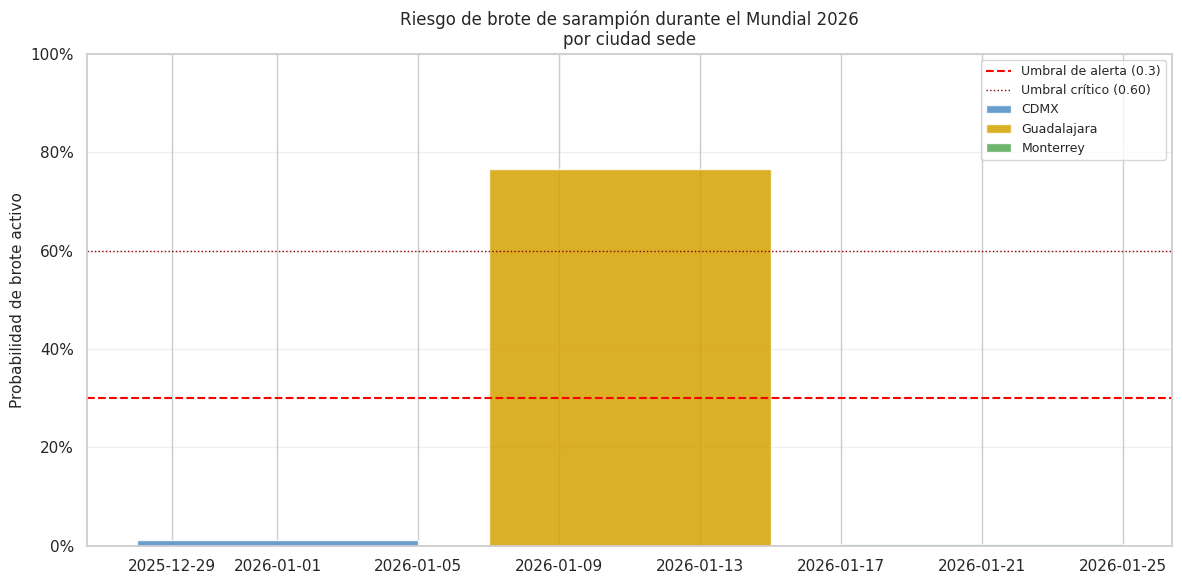

In [ ]:
# Visualización: probabilidad de brote por sede y mes
fig, ax = plt.subplots(figsize=(12, 6))

partidos_mexico = {
    '2026-06': {'CDMX':'MEX vs RSA\nEUR vs MEX', 'Guadalajara':'KOR vs EUR\nMEX vs KOR',
                'Monterrey':'UKR vs TUN\nTUN vs JPN\nRSA vs KOR'},
    '2026-07': {'CDMX':'16vos\n8vos Final'},
}

for ciudad, color in CIUDAD_COLORS.items():
    sub = panel_mundial[panel_mundial['ciudad_sede'] == ciudad].sort_values('fecha')
    if len(sub) == 0:
        continue
    ax.bar(
        sub['fecha'] + pd.Timedelta(days={'CDMX':0,'Guadalajara':10,'Monterrey':20}[ciudad]),
        sub['prob_brote'],
        width=8, color=color, alpha=0.85, label=ciudad
    )

ax.axhline(UMBRAL, color='red', linestyle='--', linewidth=1.5,
           label=f'Umbral de alerta ({UMBRAL})')
ax.axhline(0.6, color='darkred', linestyle=':', linewidth=1,
           label='Umbral crítico (0.60)')

ax.set_ylim(0, 1)
ax.set_ylabel('Probabilidad de brote activo', fontsize=11)
ax.set_title('Riesgo de brote de sarampión durante el Mundial 2026\npor ciudad sede',
             fontsize=12)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.savefig(f'{OUTPUT_FIGURES}/riesgo_mundial_2026.png', dpi=150)
plt.show()


---
## 8. Exportar predicciones y modelo

In [ ]:
import joblib

# Guardar predicciones del test
pred_test = panel[mask_test].copy()
pred_test['prob_brote'] = test_results[mejor_nombre]['y_prob']
pred_test['pred_brote'] = test_results[mejor_nombre]['y_pred']
pred_test.to_csv(DATA_PROCESSED + 'predicciones_test_2025_2026.csv', index=False)
print(f"✅ Predicciones test: {DATA_PROCESSED}predicciones_test_2025_2026.csv")

# Guardar modelo
joblib.dump(mejor_modelo, OUTPUT_MODELS + f'modelo_{mejor_nombre.lower().replace(" ","_")}.pkl')
print(f"✅ Modelo guardado: {OUTPUT_MODELS}modelo_{mejor_nombre.lower().replace(' ','_')}.pkl")

# Guardar predicciones del Mundial
if len(panel_mundial) > 0:
    panel_mundial.to_csv(DATA_PROCESSED + 'predicciones_mundial_2026.csv', index=False)
    print(f"✅ Predicciones Mundial: {DATA_PROCESSED}predicciones_mundial_2026.csv")


✅ Predicciones test: content/data/processed/predicciones_test_2025_2026.csv
✅ Modelo guardado: content/models/modelo_logistic_regression.pkl
✅ Predicciones Mundial: content/data/processed/predicciones_mundial_2026.csv


---
## 9. Conclusiones del Notebook 4

Responde estas preguntas después de correr el notebook:

1. **¿Qué modelo tuvo mejor PR-AUC?** ¿Qué recall obtuvo en el test?
   Un recall de 0.7+ significa que detecta 7 de cada 10 brotes reales.

2. **¿Cuáles fueron las features más importantes?**
   Se espera que `casos_lag1`, `brotes_6m`, `zscore_max_mes` y
   `casos_sarampion` lideren — el modelo aprende principalmente del
   historial de la misma sede.

3. **¿Qué sede tiene mayor probabilidad de brote durante el Mundial?**
   Se espera Guadalajara (brote activo con 296 casos durante sem 23-27).

4. **Limitaciones del modelo:**
   - Solo 4 brotes en train → el modelo generaliza poco desde datos históricos
   - Los brotes de 2025-2026 son el único evento de magnitud real
   - La correlación pasajeros-casos no es significativa para GDL ni MTY
   - **Recomendación:** actualizar el modelo cuando haya más semanas de datos 2026

5. **¿Qué agregarías para mejorar el modelo?**
   - Datos de cobertura vacunal por municipio (CENSIA)
   - Densidad de eventos masivos por sede
   - Temperatura/humedad (factores de transmisión)
   - Datos de movilidad Google/Meta por estado


In [ ]:
print("=== RESUMEN NOTEBOOK 4 ===")
print(f"\n── Dataset ──")
print(f"  Train: {mask_train.sum()} meses-sede | {y_train.sum()} brotes ({y_train.mean()*100:.1f}%)")
print(f"  Test:  {mask_test.sum()} meses-sede  | {y_test.sum()} brotes  ({y_test.mean()*100:.1f}%)")
print(f"  Features: {len(FEATURE_COLS)}")

print(f"\n── Resultados por modelo (Test 2025-2026) ──")
for nombre, res in sorted(test_results.items(),
                           key=lambda x: x[1]['pr_auc'], reverse=True):
    print(f"  {nombre:25s}: ROC={res['roc_auc']:.3f} | "
          f"PR={res['pr_auc']:.3f} | "
          f"F1={res['f1']:.3f} | "
          f"Recall={res['recall']:.3f}")

print(f"\n── Mejor modelo: {mejor_nombre} ──")
print(f"  Umbral de clasificación: {UMBRAL}")

if len(panel_mundial) > 0:
    print(f"\n── Predicción Mundial 2026 ──")
    for ciudad in ['CDMX','Guadalajara','Monterrey']:
        sub = panel_mundial[panel_mundial['ciudad_sede']==ciudad]
        if len(sub) > 0:
            prob_max = sub['prob_brote'].max()
            nivel    = sub['nivel_riesgo'].mode()[0] if len(sub) > 0 else 'N/A'
            print(f"  {ciudad:12s}: prob_max={prob_max:.2f} | nivel={nivel}")


=== RESUMEN NOTEBOOK 4 ===

── Dataset ──
  Train: 324 meses-sede | 4 brotes (1.2%)
  Test:  39 meses-sede  | 10 brotes  (25.6%)
  Features: 24

── Resultados por modelo (Test 2025-2026) ──
  Logistic Regression      : ROC=0.986 | PR=0.957 | F1=0.842 | Recall=0.800
  Random Forest            : ROC=0.879 | PR=0.867 | F1=0.824 | Recall=0.700
  Gradient Boosting        : ROC=0.869 | PR=0.818 | F1=0.750 | Recall=0.600
  XGBoost                  : ROC=0.750 | PR=0.628 | F1=0.667 | Recall=0.500

── Mejor modelo: Logistic Regression ──
  Umbral de clasificación: 0.3

── Predicción Mundial 2026 ──
  CDMX        : prob_max=0.01 | nivel=Bajo
  Guadalajara : prob_max=0.77 | nivel=Muy alto
  Monterrey   : prob_max=0.00 | nivel=Bajo


In [ ]:
# CELDA TEMPORAL — ver qué pasó DESPUÉS del Mundial en las 3 sedes
import pandas as pd

df = pd.read_csv('content/data/raw/boletin_epidemiologico_2016_2026.csv',
                 parse_dates=['fecha_inicio'])

SEDES_MAP = {'Ciudad de México':'CDMX','Jalisco':'Guadalajara','Nuevo León':'Monterrey'}

post_mundial = df[
    (df['enfermedad'] == 'Sarampion') &
    (df['sexo'] == 'H') &
    (df['entidad_federativa'].isin(SEDES_MAP.keys())) &
    (df['anio'] == 2026) &
    (df['semana'] >= 23)
].copy()

post_mundial['ciudad_sede'] = post_mundial['entidad_federativa'].map(SEDES_MAP)

print("Casos de sarampión POST-Mundial 2026 (sem 23 en adelante):")
print(post_mundial.groupby(['semana','ciudad_sede'])['casos_semana']
      .sum().unstack(fill_value=0).to_string())

Casos de sarampión POST-Mundial 2026 (sem 23 en adelante):
ciudad_sede  CDMX  Guadalajara  Monterrey
semana                                   
23             14          110          3
24              0            0          0
25              0            0          0
26              0            0          0
27              1           29          2
28              0            0          0
29              0            0          0
30              0            0          0
31              1            6          0
32              0            0          0
33              0            0          0
34              0            0          0
35              0            0          0
36             11          145          0
37              0            0          0
38              0            0          0
39              0            0          0
40             24          102          1
41              0            0          0
42              0            0          0
43              0

In [ ]:
# CELDA TEMPORAL — ver hasta qué semana tenemos datos reales de 2026
df_2026 = df[
    (df['enfermedad'] == 'Sarampion') &
    (df['sexo'] == 'H') &
    (df['anio'] == 2026) &
    (df['entidad_federativa'].isin(SEDES_MAP.keys()))
].copy()
df_2026['ciudad_sede'] = df_2026['entidad_federativa'].map(SEDES_MAP)

print("Datos reales 2026 por semana:")
print(df_2026.groupby(['semana','ciudad_sede'])['casos_semana']
      .sum().unstack(fill_value=0).to_string())
print(f"\nÚltima semana con datos: {df_2026['semana'].max()}")


Datos reales 2026 por semana:
ciudad_sede  CDMX  Guadalajara  Monterrey
semana                                   
1               0            9          0
2               0            0          0
3               0            0          0
4               0            0          0
5               0            0          0
6               6          119          1
7               0            0          0
8               0            0          0
9               0            0          0
10              5           48          2
11              0            0          0
12              0            0          0
13              0            0          0
14              8           60          1
15              0            0          0
16              0            0          0
17              0            0          0
18              4           85          0
19              0            0          0
20              0            0          0
21              0            0          0
22  

In [ ]:
# CELDA TEMPORAL — ver hasta qué semana tenemos datos reales de 2026
df_2026 = df[
    (df['enfermedad'] == 'Sarampion') &
    (df['sexo'] == 'H') &
    (df['anio'] == 2026) &
    (df['entidad_federativa'].isin(SEDES_MAP.keys()))
].copy()
df_2026['ciudad_sede'] = df_2026['entidad_federativa'].map(SEDES_MAP)

print("Datos reales 2026 por semana:")
print(df_2026.groupby(['semana','ciudad_sede'])['casos_semana']
      .sum().unstack(fill_value=0).to_string())
print(f"\nÚltima semana con datos: {df_2026['semana'].max()}")

Datos reales 2026 por semana:
ciudad_sede  CDMX  Guadalajara  Monterrey
semana                                   
1               0            9          0
2               0            0          0
3               0            0          0
4               0            0          0
5               0            0          0
6               6          119          1
7               0            0          0
8               0            0          0
9               0            0          0
10              5           48          2
11              0            0          0
12              0            0          0
13              0            0          0
14              8           60          1
15              0            0          0
16              0            0          0
17              0            0          0
18              4           85          0
19              0            0          0
20              0            0          0
21              0            0          0
22  